#1. import Libraries

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras import layers

#2 . Load the dataset

In [5]:
(x_train,y_train) , (x_test,y_test) = keras.datasets.cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 68s 0us/step


In [7]:
print("Training images shape :",x_train.shape)
print("Training labels shape :",y_train.shape)
print("Pixel value range:", x_train.min(), "to", x_train.max())

Training images shape : (50000, 32, 32, 3)
Training labels shape : (50000, 1)
Pixel value range: 0 to 255


In [8]:
class_names = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]

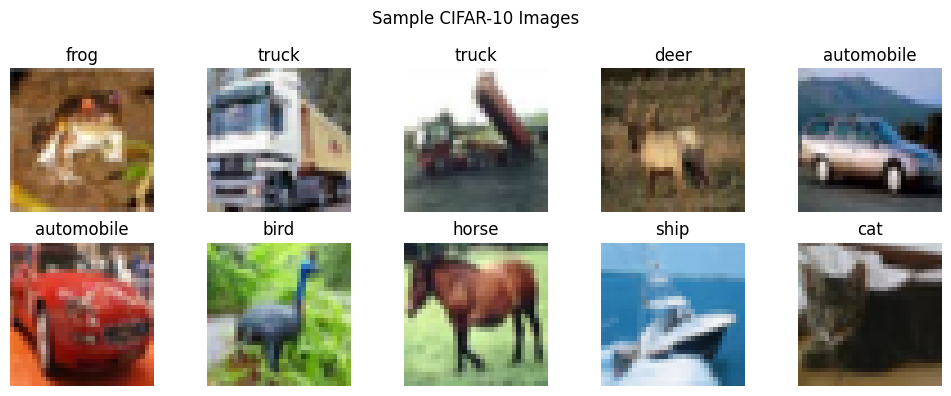

In [9]:
# --- Step 5: Visualize Some Images ---
plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(x_train[i])          # imshow shows color images (RGB)
    plt.title(class_names[y_train[i][0]])  # y_train[i] is [3], so [0] gets 3
    plt.axis('off')
plt.suptitle("Sample CIFAR-10 Images")
plt.tight_layout()
plt.show()

In [10]:
# --- Step 6: Normalize Pixel Values ---
x_train = x_train.astype('float32') / 255.0
x_test  = x_test.astype('float32') / 255.0

In [11]:
# --- Step 7: Fix Label Shape ---
y_train = y_train.flatten()   # shape: (50000, 1) → (50000,)
y_test  = y_test.flatten()  # shape: (10000, 1) → (10000,)

In [12]:
# --- Step 8: Build the CNN Model ---
model = keras.Sequential([

    # ── BLOCK 1: First Conv + Pool ──────────────────────────
    layers.Conv2D(
        filters=32,         # learn 32 different filters (patterns)
        kernel_size=(3, 3), # each filter is 3×3 pixels
        activation='relu',  # ReLU: keep positive values, kill negatives
        padding='same',     # keep output same size as input (32×32)
        input_shape=(32, 32, 3)  # MUST specify for first layer only
    ),
    # After this: shape is (32, 32, 32) — 32 filters applied

    layers.MaxPooling2D(pool_size=(2, 2)),
    # Shrinks 32×32 → 16×16  (takes max of each 2×2 block)

    layers.Dropout(0.25),
    # During training: randomly turn off 25% of neurons
    # Prevents overfitting (model memorizing instead of learning)
    # ── BLOCK 2: Second Conv + Pool ─────────────────────────
    layers.Conv2D(
        filters=64,         # 64 filters this time (more complex patterns)
        kernel_size=(3, 3),
        activation='relu',
        padding='same'
    ),
    # After this: shape is (16, 16, 64)

    layers.MaxPooling2D(pool_size=(2, 2)),
    # Shrinks 16×16 → 8×8

    layers.Dropout(0.25),


    # ── BLOCK 3: Third Conv (no pool this time) ──────────────
    layers.Conv2D(
        filters=128,        # 128 filters — very complex patterns
        kernel_size=(3, 3),
        activation='relu',
        padding='same'
    ),
    # After this: shape is (8, 8, 128)

    layers.Dropout(0.4),    # Higher dropout here — bigger layer


    # ── TRANSITION: 3D → 1D ─────────────────────────────────
    layers.Flatten(),
    # Converts (8, 8, 128) → (8192,) — one long list of numbers
    # This bridges the CNN part to the Dense (normal NN) part


    # ── DENSE LAYERS: Final Classification ──────────────────
    layers.Dense(
        units=128,          # 128 neurons
        activation='relu'
    ),
    # Learns combinations of all the detected features

    layers.Dropout(0.5),    # Strong dropout before output (50%)

    layers.Dense(
        units=10,           # 10 neurons = 10 classes
        activation='softmax'
    )
    # softmax converts raw numbers into probabilities that sum to 1.0
    # e.g. [0.01, 0.02, 0.85, 0.01, ...] → model thinks class 2 (bird)

])

# Print a summary of the model architecture
model.summary()
# Shows each layer, its output shape, and number of parameters

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,048,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,143,242 (4.36 MB)

 Trainable params: 1,143,242 (4.36 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
# --- Step 9: Compile the Model ---
model.compile(
    optimizer='adam',
    # adam = smart learning algorithm that adjusts how fast it learns
    # Good default for almost all deep learning problems

    loss='sparse_categorical_crossentropy',
    # Loss function for multi-class classification
    # 'sparse' → because labels are integers (0,1,2...) not one-hot encoded
    # (one-hot would be: 3 → [0,0,0,1,0,0,0,0,0,0])

    metrics=['accuracy']
    # Track accuracy so we can see progress during training
)

In [14]:
# --- Step 10: Train the Model ---
history = model.fit(
    x_train, y_train,
    epochs=20,
    # epochs = how many times to go through ALL training data
    # More epochs = more learning (but risk of overfitting)

    batch_size=64,
    # Process 64 images at a time (not all 50,000 at once — too slow!)
    # Each batch updates the model's weights

    validation_split=0.1,
    # Use 10% of training data (5,000 images) to validate during training
    # This is NOT the test set — just to monitor overfitting live

    verbose=1
    # Print progress (loss + accuracy) after each epoch
)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 16s 12ms/step - accuracy: 0.3724 - loss: 1.7092 - val_accuracy: 0.5272 - val_loss: 1.3615
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.5107 - loss: 1.3603 - val_accuracy: 0.6066 - val_loss: 1.1188
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.5671 - loss: 1.2208 - val_accuracy: 0.6102 - val_loss: 1.0522
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6000 - loss: 1.1318 - val_accuracy: 0.6684 - val_loss: 0.9493
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6286 - loss: 1.0592 - val_accuracy: 0.6786 - val_loss: 0.9169
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6485 - loss: 1.0014 - val_accuracy: 0.7248 - val_loss: 0.8097
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6629 - loss: 0.9623 - val_accuracy: 0.7202 - val_loss: 0.8011
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6754 - loss: 0.9276 - val_accuracy: 

In [15]:
# --- Step 11: Evaluate on Test Data ---
test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=0)
print(f"\nTest Accuracy: {test_accuracy:.4f}")
print(f"Test Loss:     {test_loss:.4f}")
# This is the REAL score — data the model has never seen before


Test Accuracy: 0.7366
Test Loss:     0.7718


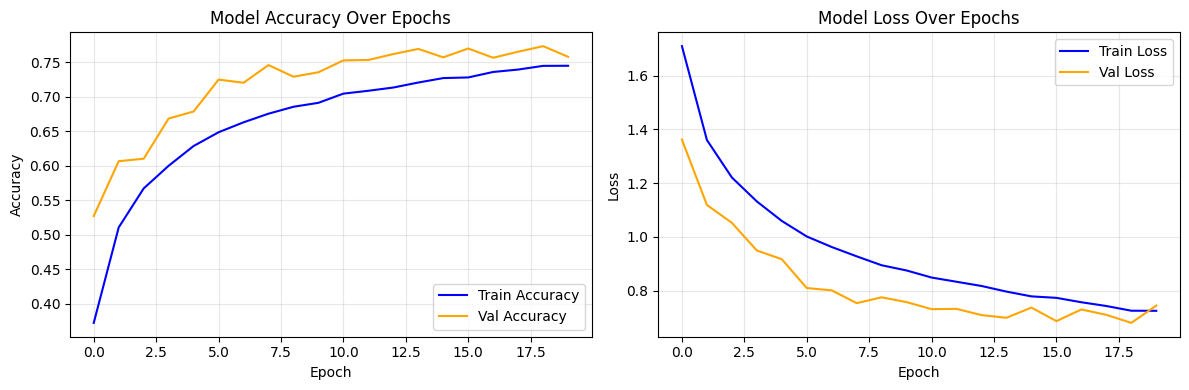

In [16]:
# --- Step 12: Plot Training History ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Accuracy plot
ax1.plot(history.history['accuracy'],     label='Train Accuracy', color='blue')
ax1.plot(history.history['val_accuracy'], label='Val Accuracy',   color='orange')
ax1.set_title('Model Accuracy Over Epochs')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Loss plot
ax2.plot(history.history['loss'],     label='Train Loss', color='blue')
ax2.plot(history.history['val_loss'], label='Val Loss',   color='orange')
ax2.set_title('Model Loss Over Epochs')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# If Train Accuracy >> Val Accuracy → OVERFITTING (model memorized data)
# If both are low → UNDERFITTING (model didn't learn enough)
# Goal: both high and close together!

In [17]:
# --- Step 13: Make Predictions ---
predictions = model.predict(x_test)
# predictions shape: (10000, 10) — 10 probabilities per image

# Look at first prediction
first_pred = predictions[0]
print("\nProbabilities for first image:")
for i, prob in enumerate(first_pred):
    print(f"  {class_names[i]:12s}: {prob:.4f}")

predicted_class = np.argmax(first_pred)
# np.argmax → finds the index with the highest probability
actual_class = y_test[0]

print(f"\nPredicted: {class_names[predicted_class]}")
print(f"Actual:    {class_names[actual_class]}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

Probabilities for first image:
  airplane    : 0.0008
  automobile  : 0.0011
  bird        : 0.0060
  cat         : 0.6901
  deer        : 0.0025
  dog         : 0.1221
  frog        : 0.1683
  horse       : 0.0003
  ship        : 0.0074
  truck       : 0.0013

Predicted: cat
Actual:    cat


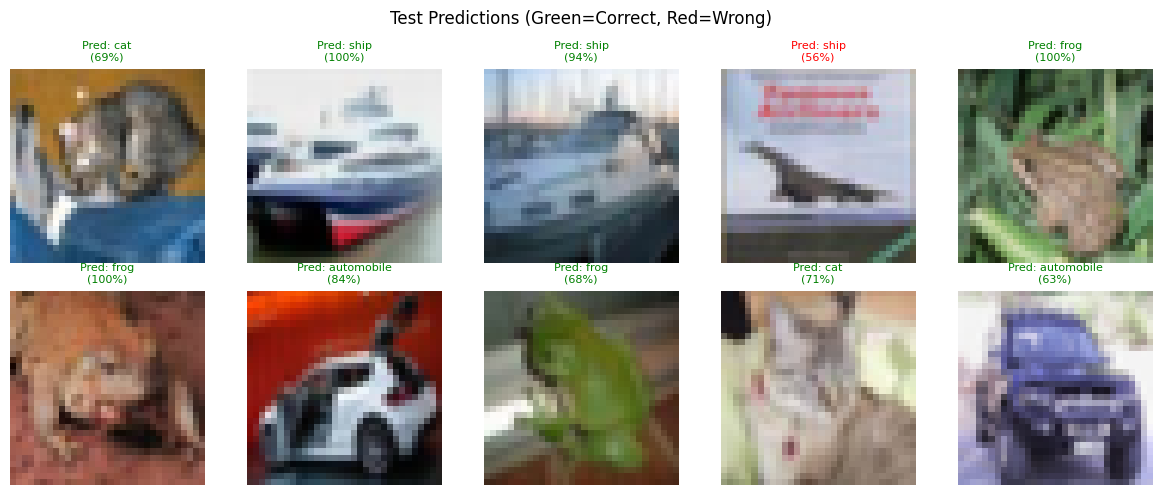

In [18]:
# --- Step 14: Visualize Predictions ---
plt.figure(figsize=(12, 5))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(x_test[i])

    pred = class_names[np.argmax(predictions[i])]
    true = class_names[y_test[i]]
    conf = np.max(predictions[i]) * 100  # confidence %

    color = 'green' if pred == true else 'red'
    plt.title(f"Pred: {pred}\n({conf:.0f}%)", color=color, fontsize=8)
    plt.axis('off')

plt.suptitle("Test Predictions (Green=Correct, Red=Wrong)")
plt.tight_layout()
plt.show()